# Example 2: Tissue Segmentation
---

This example demonstrates how to perform tissue segmentation for a single slide using HistoKit. 

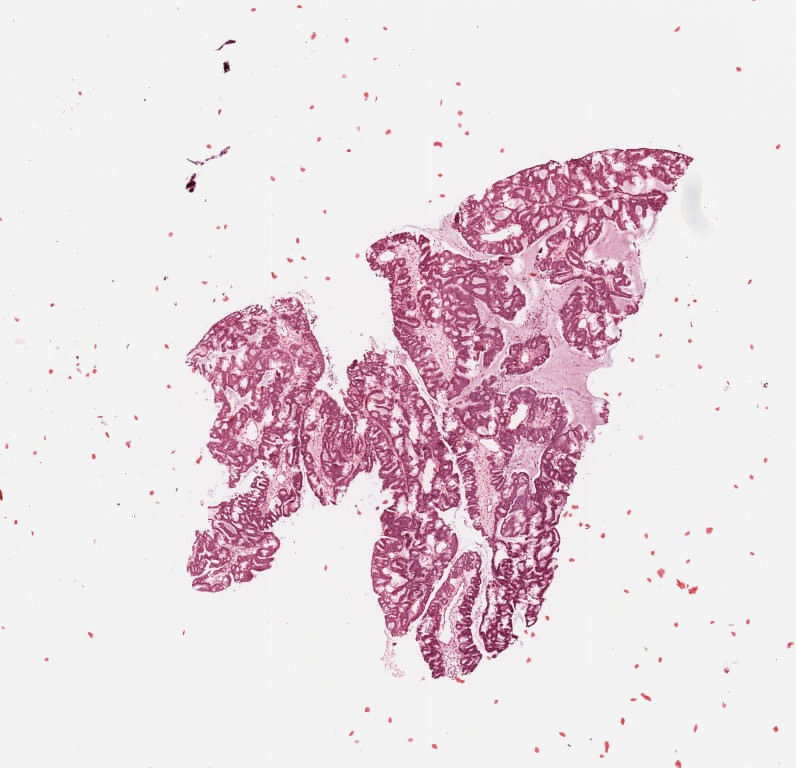

In [8]:
from histokit.slide.slide import Slide

# Read a WSI in SVS format
path = "Data/C3N-02274-22.svs"
s = Slide(path)

s.assoctiated_images["thumbnail"]

In [9]:
from histokit.savers.base import Saver
from histokit.segmentation.artifact.grandqc.config import GrandQCConfig
from histokit.segmentation.artifact.grandqc.segmenter import GrandQCSegmenter
from histokit.segmentation.tissue.gamred.config import GaMRedConfig
from histokit.segmentation.tissue.gamred.segmenter import GaMRedSegmenter

config = GaMRedConfig()
res = GaMRedSegmenter(config).segment(s, basename="C3N-02274-22", verbose=True, save = False)


Segmenting tissue for the slide: C3N-02274-22 using GaMRed algorithm...


In [10]:
for key, value in res.items():
    print(f"{key}: {value}")

basename: C3N-02274-22
method: GaMRed
type: tissue_mask
mask: [array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), array([[255,   0],
       [255, 255]], dtype=uint8), array([[255],
       [255]], dtype=uint8), array([[  0, 255,   0],
       [255, 255, 255]], dtype=uint8)]
bbox: [[117  92 317 317]
 [349 101   2   2]
 [396 151   1   2]
 [130 316   3   2]]
mag_det: 2.5
mag_save: 1.0
mag_l0: 20.0
mpp_l0: 0.4942
level_dimensions_0: [9959 9603]
thr: {'R': 227.9818037981804, 'G': 226.26325662632567, 'B': 226.77119117711914}
config: {'saver': 'hdf5', 'out_dir': './outputs', 'save_mag': 1.0, 'collectors': [{'name': 'ThumbnailCollector'}, {'name': 'SegmentationOverlayCollector'}, {'name': 'HistogramCollector'}], 'vis_mag': 1.0, 'tissdet_mag': 2.5, 'thr_min': 178.5, 'split_regions': True, 'remove_green_pen': True, 'thr_green_pen': 

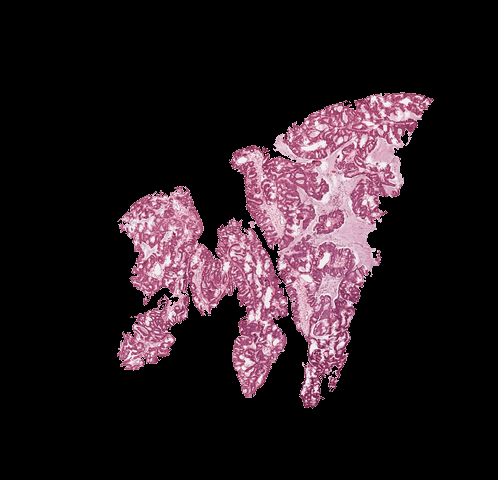

In [11]:
s.read_masked_slide(res["bbox"], res["mask"], mag=1, mag_bbox = res["mag_save"])

In [12]:
config = GrandQCConfig(model_path = "C:\\Repos\\HistoKit\\models\\GrandQC_MPP1.pth")
#tissue_mask = res,
res_qc = GrandQCSegmenter(config).segment(slide = s, basename = "C3N-02274-22",  verbose = True, save = False, tissue_mask = res)

Segmenting artifacts for slide: C3N-02274-22 using GrandQC...
Processing tissue region 1/4
Processing tissue region 2/4
Processing tissue region 3/4
Processing tissue region 4/4


In [13]:
for key, value in res_qc.items():
    print(f"{key}: {value}")

basename: C3N-02274-22
method: GrandQC
type: artifact_mask
mask: [array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]]), array([[7, 0],
       [7, 7]]), array([[7],
       [7]]), array([[0, 7, 0],
       [7, 7, 7]])]
bbox: [array([117.,  92., 434., 409.]), array([349., 101., 351., 103.]), array([396., 151., 397., 153.]), array([130., 316., 133., 318.])]
raw_mask: [array([[[1.00000000e+00, 1.93978196e-21, 5.73460868e-18, ...,
         9.88892239e-17, 4.99847150e-20, 1.00000000e+00],
        [1.00000000e+00, 2.93980338e-22, 2.05955668e-18, ...,
         6.27028646e-17, 6.05251350e-20, 1.00000000e+00],
        [1.00000000e+00, 8.02704783e-23, 1.16261011e-18, ...,
         4.22437433e-17, 6.83225724e-20, 1.00000000e+00],
        ...,
        [1.00000000e+00, 8.37709394e-20, 1.07378876e-16, ...,
         9.95957009e-16, 4.08231339e-19, 1.0000

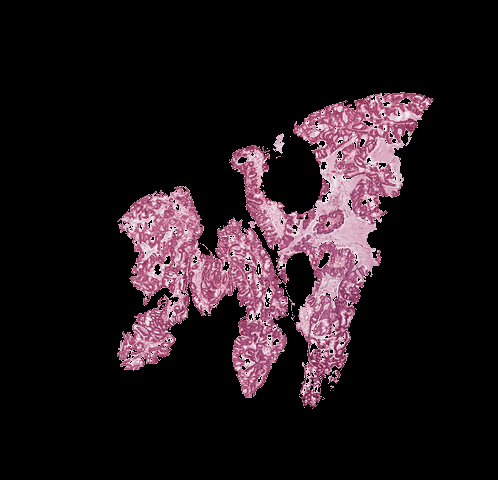

In [14]:
s.read_masked_slide(res_qc["bbox"], res_qc["mask"], mag=1, mag_bbox = res_qc["mag_save"])